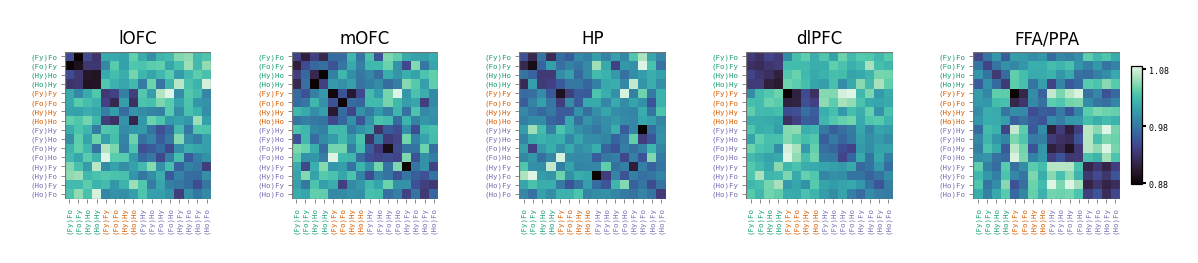

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])
mm = 1 / 25.4
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
GREY_LIGHT = "#b4aea9"
GREY_DARK = "#747473"
def plot_rdm(ax, rdm, categories):
    mask = np.tril(np.ones_like(rdm, dtype=bool))
    mask = np.fliplr(mask)
    categories_flip = np.flip(categories)
    im = sns.heatmap(rdm, cmap='mako',cbar= False,linecolor=GREY_DARK,
                square=True, xticklabels=categories, yticklabels=categories,ax=ax)

    ax.set_xticklabels(categories, rotation=90, fontsize=1.8)
    ax.set_yticklabels(categories, fontsize=1.8)
    #ax.xaxis.tick_top()
    labels = ax.get_xmajorticklabels()
    for label in labels:
        text = label.get_text()
        if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
            label.set_color('#1B9E77')
        elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
            label.set_color('#D95F02')
        else:
            label.set_color('#7570B3')
    labels1 = ax.get_ymajorticklabels()
    for label1 in labels1:
        text = label1.get_text()
        if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
            label1.set_color('#1B9E77')
        elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
            label1.set_color('#D95F02')
        else:
            label1.set_color('#7570B3')
    ax.tick_params(axis='both', which='major', length=1.0, width=0.2,color = GREY_DARK)
    ax.tick_params(axis='both', which='major', pad=0.8)
    rect = patches.Rectangle((0,0),1,1,linewidth=0.3,edgecolor=GREY_DARK,facecolor='none', transform=ax.transAxes)
    ax.add_patch(rect) 
    plt.tight_layout()
    return im
titles = ['lOFC', 'mOFC', 'HP', 'dlPFC', 'FFA/PPA']
rdm_files = ['lofc_matrices.npy','mofc_matrices.npy','hp_matrices.npy','dlPFC_matrices.npy','FFA-PPA_matrices.npy']
f, axs = plt.subplots(1, len(rdm_files), figsize=(100 * mm, 50 * mm), dpi=300)
for i, rdm_file in enumerate(rdm_files):
    rdm = np.load(f'/media/garlicseed/data/final/RSA/rdm_matrix/average/{rdm_file}')
    im = plot_rdm(axs[i], rdm, categories)  
    axs[i].set_title(titles[i],fontsize=4,y=0.89, fontdict={'family': 'DejaVu Sans'})
cbar_ax = f.add_axes([0.97, 0.40, 0.01, 0.2])
cbar = f.colorbar(im.collections[0], cax=cbar_ax)
cbar.outline.set_linewidth(0.3)
cbar.set_ticks([0.88, 0.98,1.08])
cbar.ax.tick_params(labelsize=2.0, length=1.0,pad = 0.5,width=0.5)

plt.savefig(f"/media/garlicseed/data/final/RSA/rdm_matrix/Figures/average_rdm.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig(f"/media/garlicseed/data/final/RSA/rdm_matrix/Figures/average_rdm.png", dpi=300, format="png", bbox_inches='tight')